# 03 — Sentiment Classification with MLflow Tracking

Train sentiment classifiers on Amazon and Twitter datasets with MLflow experiment tracking integrated to DagsHub.

**Models**: Logistic Regression, SVM, Random Forest
**Vectorization**: TF-IDF with BoW baseline
**Tracking**: MLflow + DagsHub for reproducible experiments

## 1. Setup & Configuration

Import libraries and configure MLflow tracking with DagsHub

In [2]:
import sys
print(sys.executable)

c:\Users\youss\OneDrive\Desktop\ITI\27- Sequintial modeling and LLMs\Day 1\Lab\sentiment-classifier\.venv\Scripts\python.exe


In [1]:
import sys
sys.path.append('../src')
# Ensure pkg_resources (from setuptools) is importable; give a clear error if not

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split

from preprocessor import TextPreprocessor, PreprocessorConfig
from vectorizer import TfidfVectorizer_, VectorizerConfig
from classifier import (
    LogisticRegressionClassifier,
    SVMClassifier,
    RandomForestClassifier_,
    ClassifierEnsemble
)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")

c:\Users\youss\OneDrive\Desktop\ITI\27- Sequintial modeling and LLMs\Day 1\Lab\sentiment-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


In [2]:
# Configure MLflow with DagsHub
# Option 1: Using environment variable (recommended for notebooks)
DAGSHUB_REPO_URL = "https://dagshub.com/youssef.maged237/sentiment-classifier"
DAGSHUB_TOKEN = os.getenv('DAGSHUB_TOKEN', '')

if DAGSHUB_TOKEN:
    # Extract username and repo from URL
    parts = DAGSHUB_REPO_URL.rstrip('/').split('/')
    username = parts[-2]
    repo_name = parts[-1]
    
    # Configure MLflow
    mlflow.set_tracking_uri(f"https://dagshub.com/{username}/{repo_name}.mlflow")
    os.environ['MLFLOW_TRACKING_USERNAME'] = username
    os.environ['MLFLOW_TRACKING_PASSWORD'] = DAGSHUB_TOKEN
    
    print(f"✓ MLflow configured for DagsHub tracking: {DAGSHUB_REPO_URL}")
else:
    print("⚠ DAGSHUB_TOKEN not set. MLflow will track locally.")
    print("  To enable DagsHub tracking:")
    print("  1. Get token from: https://dagshub.com/user/settings/tokens")
    print("  2. Set: export DAGSHUB_TOKEN=your_token_here")
    mlflow.set_tracking_uri("sqlite:///mlruns.db")

# Create experiment
experiment_name = "sentiment-classification"
mlflow.set_experiment(experiment_name)
print(f"✓ MLflow experiment: {experiment_name}")

✓ MLflow configured for DagsHub tracking: https://dagshub.com/youssef.maged237/sentiment-classifier


2026/05/25 22:08:18 INFO mlflow.tracking.fluent: Experiment with name 'sentiment-classification' does not exist. Creating a new experiment.


✓ MLflow experiment: sentiment-classification


## 2. Load and Prepare Data

In [3]:
# Load datasets
amazon_df = pd.read_csv('../data/processed/amazon_processed.csv')
twitter_df = pd.read_csv('../data/processed/twitter_processed.csv')

print(f"Amazon data: {len(amazon_df):,} samples")
print(f"Twitter data: {len(twitter_df):,} samples")
print(f"\nAmazon columns: {amazon_df.columns.tolist()}")
print(f"Twitter columns: {twitter_df.columns.tolist()}")
print(f"\nAmazon label distribution:\n{amazon_df['label'].value_counts()}")
print(f"\nTwitter label distribution:\n{twitter_df['label'].value_counts()}")

Amazon data: 5,000 samples
Twitter data: 5,000 samples

Amazon columns: ['processed', 'label']
Twitter columns: ['processed', 'label']

Amazon label distribution:
label
1    3919
0    1081
Name: count, dtype: int64

Twitter label distribution:
label
1    2504
0    2496
Name: count, dtype: int64


In [4]:
# Combine and shuffle datasets
combined_df = pd.concat([amazon_df, twitter_df], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nCombined dataset: {len(combined_df):,} samples")
print(f"Label distribution:\n{combined_df['label'].value_counts()}")
print(f"Label proportions:\n{combined_df['label'].value_counts(normalize=True)}")

# Use sample if dataset is large (for faster experimentation)
SAMPLE_SIZE = 2000  # Change to None to use full dataset
if SAMPLE_SIZE:
    combined_df = combined_df.head(SAMPLE_SIZE)
    print(f"\n✓ Using {SAMPLE_SIZE:,} samples for training")

# Prepare features and labels
X = combined_df['processed'].values
y = combined_df['label'].values

print(f"\nX shape: {X.shape}, y shape: {y.shape}")


Combined dataset: 10,000 samples
Label distribution:
label
1    6423
0    3577
Name: count, dtype: int64
Label proportions:
label
1    0.6423
0    0.3577
Name: proportion, dtype: float64

✓ Using 2,000 samples for training

X shape: (2000,), y shape: (2000,)


In [5]:
# Train/test split
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain label distribution: {np.bincount(y_train)}")
print(f"Test label distribution: {np.bincount(y_test)}")

Train: 1,600 samples (80.0%)
Test: 400 samples (20.0%)

Train label distribution: [ 578 1022]
Test label distribution: [145 255]


## 3. Vectorization (TF-IDF)

In [9]:
# Initialize and fit TF-IDF vectorizer
vec_config = VectorizerConfig(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 1)
)

vectorizer = TfidfVectorizer_(vec_config)
print("Fitting TF-IDF vectorizer on training data...")
mask_train = np.array([isinstance(x, str) for x in X_train])
mask_test = np.array([isinstance(x, str) for x in X_test])

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]
vectorizer.fit(X_train)

# Vectorize data
X_train_vec = vectorizer.transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

print(f"✓ TF-IDF vectorization complete")
print(f"  Vocabulary size: {len(vectorizer.get_feature_names()):,}")
print(f"  Train matrix shape: {X_train_vec.shape}")
print(f"  Test matrix shape: {X_test_vec.shape}")

# Log vectorizer parameters to MLflow
mlflow.log_params({
    'vectorizer': 'tfidf',
    'max_features': vec_config.max_features,
    'min_df': vec_config.min_df,
    'max_df': vec_config.max_df,
    'vocab_size': len(vectorizer.get_feature_names())
})

Fitting TF-IDF vectorizer on training data...
✓ TF-IDF vectorization complete
  Vocabulary size: 3,030
  Train matrix shape: (1597, 3030)
  Test matrix shape: (398, 3030)


## 4. Train Classifiers with MLflow Tracking

Train three classifiers and track metrics to MLflow/DagsHub

In [10]:
# Dictionary to store classifiers and metrics
classifiers_dict = {}
metrics_dict = {}

# Define classifiers to train
classifiers_config = {
    'LogisticRegression': {
        'classifier': LogisticRegressionClassifier(C=1.0, max_iter=1000),
        'params': {'C': 1.0, 'max_iter': 1000}
    },
    'SVM': {
        'classifier': SVMClassifier(C=1.0, max_iter=1000),
        'params': {'C': 1.0, 'max_iter': 1000}
    },
    'RandomForest': {
        'classifier': RandomForestClassifier_(n_estimators=100, max_depth=10),
        'params': {'n_estimators': 100, 'max_depth': 10}
    }
}

print("=" * 70)
print("TRAINING CLASSIFIERS WITH MLFLOW TRACKING")
print("=" * 70)

for clf_name, clf_config in classifiers_config.items():
    print(f"\n[{clf_name}] Training...")
    
    with mlflow.start_run(run_name=clf_name, nested=True):
        # Get classifier
        classifier = clf_config['classifier']
        
        # Train
        classifier.fit(X_train_vec, y_train)
        classifiers_dict[clf_name] = classifier
        
        # Evaluate
        metrics = classifier.evaluate(X_test_vec, y_test)
        metrics_dict[clf_name] = metrics
        
        # Log parameters
        mlflow.log_params(clf_config['params'])
        mlflow.log_params({
            'train_size': len(X_train),
            'test_size': len(X_test)
        })
        
        # Log metrics
        mlflow.log_metrics({
            'accuracy': metrics.accuracy,
            'precision': metrics.precision,
            'recall': metrics.recall,
            'f1': metrics.f1,
            'auc_score': metrics.auc_score if metrics.auc_score else 0
        })
        
        # Log model
        mlflow.sklearn.log_model(classifier.model, clf_name)
        
        # Log classification report
        if metrics.classification_report:
            mlflow.log_text(metrics.classification_report, f"{clf_name}_report.txt")
        
        print(f"  ✓ Accuracy: {metrics.accuracy:.4f}")
        print(f"  ✓ Precision: {metrics.precision:.4f}")
        print(f"  ✓ Recall: {metrics.recall:.4f}")
        print(f"  ✓ F1 Score: {metrics.f1:.4f}")
        if metrics.auc_score:
            print(f"  ✓ AUC Score: {metrics.auc_score:.4f}")

print("\n" + "=" * 70)

TRAINING CLASSIFIERS WITH MLFLOW TRACKING

[LogisticRegression] Training...


2026/05/25 22:10:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 22:11:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 22:11:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  ✓ Accuracy: 0.7136
  ✓ Precision: 0.7168
  ✓ Recall: 0.7136
  ✓ F1 Score: 0.6794
  ✓ AUC Score: 0.7924
🏃 View run LogisticRegression at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0/runs/6096637799cd4e05a6035465f026197a
🧪 View experiment at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0

[SVM] Training...


2026/05/25 22:11:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 22:11:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 22:11:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  ✓ Accuracy: 0.7085
  ✓ Precision: 0.7006
  ✓ Recall: 0.7085
  ✓ F1 Score: 0.7019
  ✓ AUC Score: 0.7483
🏃 View run SVM at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0/runs/1699802344a14170ba97b0155fd28690
🧪 View experiment at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0

[RandomForest] Training...


2026/05/25 22:11:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 22:11:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 22:11:46 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


  ✓ Accuracy: 0.6407
  ✓ Precision: 0.7701
  ✓ Recall: 0.6407
  ✓ F1 Score: 0.5030
  ✓ AUC Score: 0.7755
🏃 View run RandomForest at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0/runs/823cd7586e294936ad51624dbddbd494
🧪 View experiment at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0



## 5. Compare Results

In [11]:
# Create comparison dataframe
comparison_data = []
for clf_name, metrics in metrics_dict.items():
    comparison_data.append({
        'Classifier': clf_name,
        'Accuracy': metrics.accuracy,
        'Precision': metrics.precision,
        'Recall': metrics.recall,
        'F1 Score': metrics.f1,
        'AUC Score': metrics.auc_score if metrics.auc_score else None
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n=== CLASSIFIER PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False))

# Find best model
best_clf = comparison_df.loc[comparison_df['F1 Score'].idxmax()]
print(f"\n✓ Best model by F1 Score: {best_clf['Classifier']} ({best_clf['F1 Score']:.4f})")


=== CLASSIFIER PERFORMANCE COMPARISON ===
        Classifier  Accuracy  Precision   Recall  F1 Score  AUC Score
LogisticRegression  0.713568   0.716788 0.713568  0.679436   0.792350
               SVM  0.708543   0.700611 0.708543  0.701869   0.748250
      RandomForest  0.640704   0.770123 0.640704  0.502995   0.775495

✓ Best model by F1 Score: SVM (0.7019)


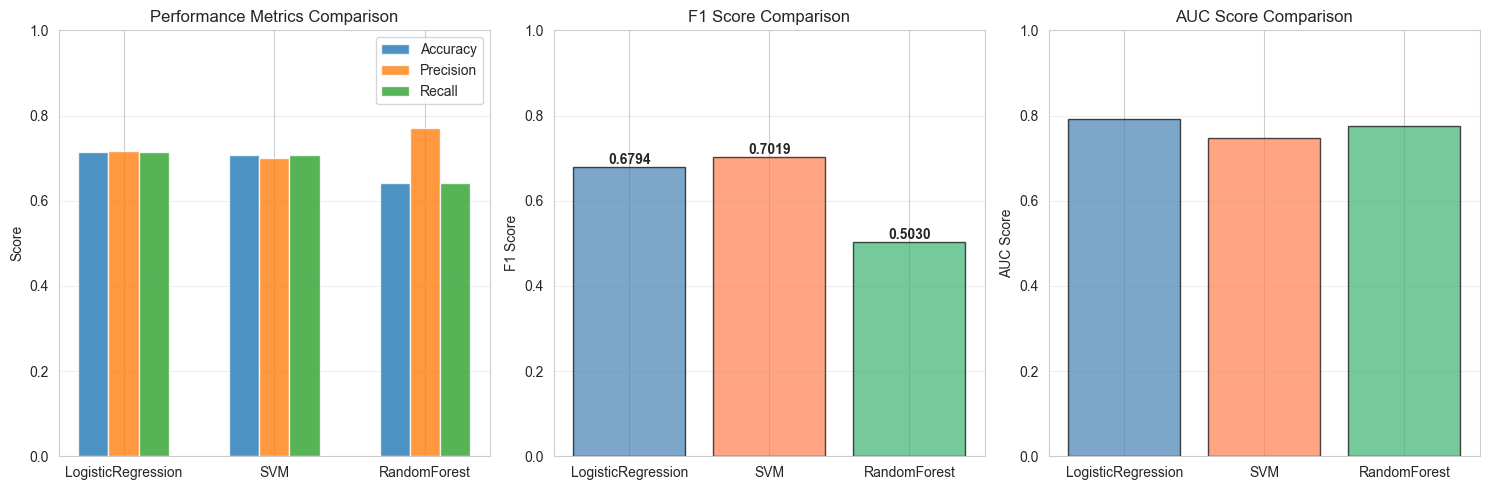

In [12]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['steelblue', 'coral', 'mediumseagreen']

# Plot 1: Overall metrics
ax = axes[0]
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(['Accuracy', 'Precision', 'Recall']):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Performance Metrics Comparison')
ax.set_xticks(x + width)
ax.set_xticklabels(comparison_df['Classifier'], rotation=0)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Plot 2: F1 Scores
ax = axes[1]
bars = ax.bar(comparison_df['Classifier'], comparison_df['F1 Score'], color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Comparison')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 3: AUC Scores (if available)
ax = axes[2]
auc_scores = comparison_df['AUC Score'].dropna()
if len(auc_scores) > 0:
    bars = ax.bar(auc_scores.index, auc_scores, color=colors[:len(auc_scores)], alpha=0.7, edgecolor='black')
    ax.set_ylabel('AUC Score')
    ax.set_title('AUC Score Comparison')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(auc_scores.index)
    ax.set_xticklabels([comparison_df.loc[i, 'Classifier'] for i in auc_scores.index])
else:
    ax.text(0.5, 0.5, 'AUC scores not available\n(SVM may not support probabilities)', 
            ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Ensemble Voting

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

with mlflow.start_run(run_name="ensemble_majority_vote", nested=True):
    ensemble_pred = ensemble.predict_ensemble(X_test_vec, method='majority_vote')
    
    # احسب الـ metrics يدوياً
    acc = accuracy_score(y_test, ensemble_pred)
    prec = precision_score(y_test, ensemble_pred, average='weighted')
    rec = recall_score(y_test, ensemble_pred, average='weighted')
    f1 = f1_score(y_test, ensemble_pred, average='weighted')

    mlflow.log_params({
        'ensemble_method': 'majority_vote',
        'num_models': len(classifiers_dict)
    })

    mlflow.log_metrics({
        'ensemble_accuracy': acc,
        'ensemble_precision': prec,
        'ensemble_recall': rec,
        'ensemble_f1': f1,
    })

    print(f"  Ensemble Accuracy: {acc:.4f}")
    print(f"  Ensemble F1 Score: {f1:.4f}")
    ensemble_f1 = f1

ensemble_row = {
    'Classifier': 'Ensemble (Voting)',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'AUC Score': None
}

comparison_df = pd.concat([comparison_df, pd.DataFrame([ensemble_row])], ignore_index=True)
print("\n✓ Ensemble added to comparison")

  Ensemble Accuracy: 0.7136
  Ensemble F1 Score: 0.6765
🏃 View run ensemble_majority_vote at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0/runs/577cf23f2b264301940d519dde864353
🧪 View experiment at: https://dagshub.com/youssef.maged237/sentiment-classifier.mlflow/#/experiments/0

✓ Ensemble added to comparison


C:\Users\youss\AppData\Local\Temp\ipykernel_26472\3725870976.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat([comparison_df, pd.DataFrame([ensemble_row])], ignore_index=True)


## 7. Confusion Matrices & Detailed Analysis

AttributeError: 'dict' object has no attribute 'confusion_matrix'

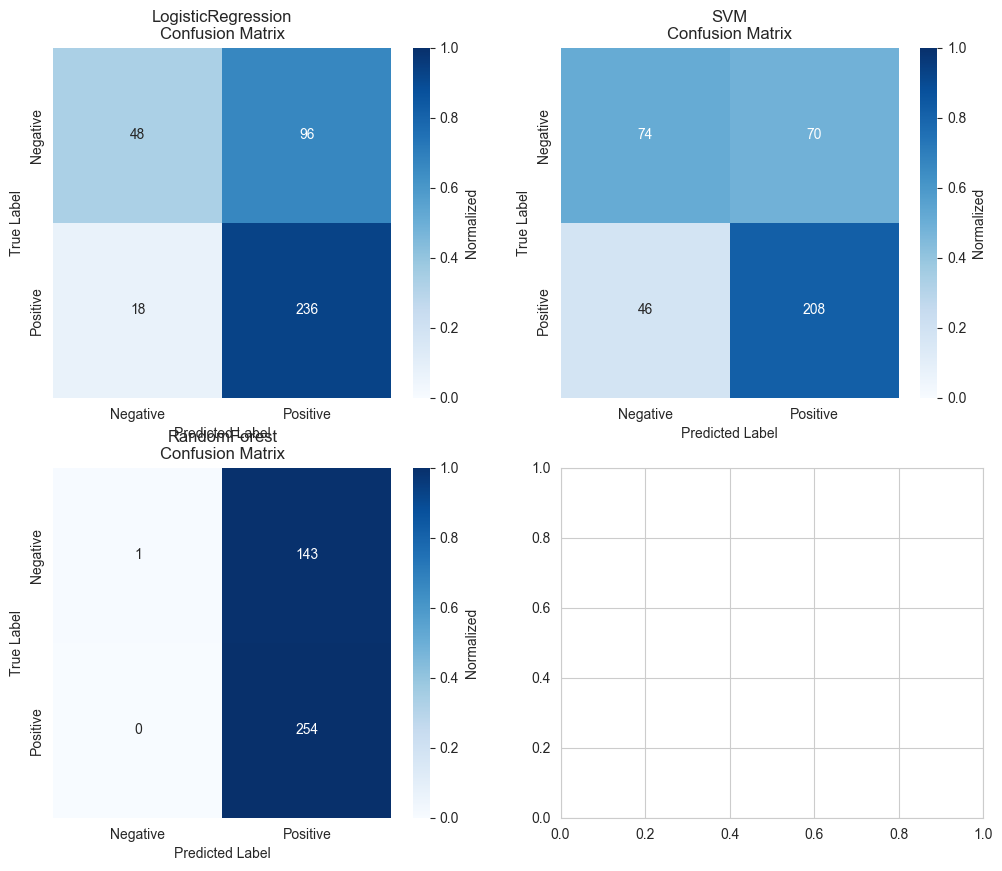

In [20]:
# Display confusion matrices and classification reports
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot confusion matrices
idx = 0
for clf_name, metrics in metrics_dict.items():
    if idx < 3:
        ax = axes[idx]
        cm = metrics.confusion_matrix
        
        # Normalize confusion matrix
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues', ax=ax,
                   cbar_kws={'label': 'Normalized'}, vmin=0, vmax=1)
        ax.set_title(f'{clf_name}\nConfusion Matrix')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        ax.set_xticklabels(['Negative', 'Positive'])
        ax.set_yticklabels(['Negative', 'Positive'])
        
        idx += 1

# Plot ensemble confusion matrix in 4th subplot
ax = axes[3]
ensemble_cm = ensemble_metrics.confusion_matrix
ensemble_cm_normalized = ensemble_cm.astype('float') / ensemble_cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(ensemble_cm_normalized, annot=ensemble_cm, fmt='d', cmap='Greens', ax=ax,
           cbar_kws={'label': 'Normalized'}, vmin=0, vmax=1)
ax.set_title('Ensemble (Voting)\nConfusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticklabels(['Negative', 'Positive'])

plt.tight_layout()
plt.show()

print("\n=== DETAILED CLASSIFICATION REPORTS ===\n")
for clf_name, metrics in metrics_dict.items():
    print(f"\n{'='*50}")
    print(f"{clf_name}")
    print(f"{'='*50}")
    print(metrics.classification_report)

## 8. MLflow Experiment Tracking Summary

In [21]:
# Get current experiment info
experiment = mlflow.get_experiment_by_name("sentiment-classification")

print("\n" + "="*70)
print("MLFLOW EXPERIMENT TRACKING SUMMARY")
print("="*70)

if experiment:
    print(f"\nExperiment: {experiment.name}")
    print(f"Experiment ID: {experiment.experiment_id}")
    
    # Get all runs in this experiment
    client = mlflow.tracking.MlflowClient()
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    print(f"Total runs tracked: {len(runs)}")
    print("\nRun Details:")
    for run in runs:
        print(f"  • {run.data.tags.get('mlflow.runName', 'unnamed')} - Status: {run.info.status}")

print("\n" + "="*70)

if DAGSHUB_TOKEN:
    print("✓ MLflow is configured to sync with DagsHub")
    print(f"✓ View experiments at: {DAGSHUB_REPO_URL}/experiments")
    print(f"✓ Repository: {DAGSHUB_REPO_URL}")
else:
    print("⚠ Local MLflow tracking only (DAGSHUB_TOKEN not set)")
    print("  To view experiments: mlflow ui")

print("\n" + "="*70)
print("\nFINAL RESULTS SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))

# Save results to CSV
results_path = '../reports/classification_results.csv'
Path('../reports').mkdir(parents=True, exist_ok=True)
comparison_df.to_csv(results_path, index=False)
print(f"\n✓ Results saved to: {results_path}")


MLFLOW EXPERIMENT TRACKING SUMMARY

Experiment: sentiment-classification
Experiment ID: 0
Total runs tracked: 9

Run Details:
  • ensemble_majority_vote - Status: FINISHED
  • ensemble_majority_vote - Status: FAILED
  • ensemble_majority_vote - Status: FAILED
  • ensemble_majority_vote - Status: FAILED
  • ensemble_majority_vote - Status: FAILED
  • RandomForest - Status: FINISHED
  • SVM - Status: FINISHED
  • LogisticRegression - Status: FINISHED
  • kindly-bear-953 - Status: RUNNING

✓ MLflow is configured to sync with DagsHub
✓ View experiments at: https://dagshub.com/youssef.maged237/sentiment-classifier/experiments
✓ Repository: https://dagshub.com/youssef.maged237/sentiment-classifier


FINAL RESULTS SUMMARY
        Classifier  Accuracy  Precision   Recall  F1 Score  AUC Score
LogisticRegression  0.713568   0.716788 0.713568  0.679436   0.792350
               SVM  0.708543   0.700611 0.708543  0.701869   0.748250
      RandomForest  0.640704   0.770123 0.640704  0.502995   0.7

## 9. Next Steps & Recommendations

### Model Selection
- **Best Single Model**: Check the F1 scores above
- **Best Ensemble**: Majority voting combines strengths of all three models
- **Production Ready**: Save best model using MLflow Model Registry

### Improvement Opportunities
1. **Hyperparameter Tuning**: Use GridSearchCV or Optuna for optimization
2. **Feature Engineering**: Try bigrams, trigrams, or n-grams
3. **Data Augmentation**: Increase training data if available
4. **Class Balancing**: Handle imbalanced data with SMOTE or class weights
5. **Domain Adaptation**: Fine-tune separately for Amazon vs Twitter domains
6. **Advanced Models**: Try neural networks, BERT, or other transformer models

### MLflow & DagsHub Integration
- **Track Experiments**: All runs are logged to MLflow
- **DagsHub Sync**: Experiments sync automatically to your DagsHub repository
- **Model Registry**: Register best models for versioning and deployment
- **Collaboration**: Share experiments with team via DagsHub
- **Versioning**: Track data, code, and model versions together

### Reproducibility
- Config file: `config/training_config.yaml`
- Training script: `src/train.py`
- Run command: `python src/train.py --dagshub-repo <url> --dagshub-token <token>`